In [1]:
import numpy as np
import torch
import torch.nn as nn
import sys
sys.path.append("../../")
from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE
from torch.utils.data import DataLoader, Dataset
from vi_rnn.datasets import Reaching, Reaching_Teacher
from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from vi_rnn.utils import *
import matplotlib.pyplot as plt
from vi_rnn.saving import save_model, load_model
from py_rnn.default_params import get_default_params

%matplotlib inline

In [2]:
train_teacher =False # load already trained teacher model
data_dir = "../../data/student_teacher/"  # store inferred model
model_dir = "../../models/students/"  # store teacher RNN
cuda = True  # toggle if GPU is available

In [3]:
# initialise teacher RNN
model_params, training_params = get_default_params(n_rec=60)
training_params["n_epochs"] = 1000
training_params["l2_rates_reg"] = 0.1
model_params['rank']= 1
model_params['n_inp'] = 4
rnn_reach = RNN(model_params)



In [4]:
from mante import generate_mante_data
class Mante(Dataset): 

    def __init__(self, task_params={}): 
        """
        Initialize a random dot motion / perceptual decision making
         / evidence integration task (for teacher network)
        Args:
            task_params: dictionary containing task parameters

        Based on https://github.com/adrian-valente/populations_paper_code/blob/master/low_rank_rnns/rdm.py
        Dubreuil A., Valente A., Beiran M., Mastrogiuseppe F., Ostojic S. 
        The role of population structure in computations through neural dynamics
        Nature Neuroscience volume 25, pages 783–794 (2022)
        """

        self.task_params = {"name": "mante"}
        
        if "coherences" not in task_params or task_params["coherences"] is None:
            self.coherences = [-4, -2, -1, 1, 2, 4]
        else:
            self.coherences = task_params["coherences"]


    def __len__(self):
        return len(self.coherences)

    def __getitem__(self, idx):
        """
        Returns a trial

        Args:
            idx, trial index

        Returns:
            input, Tensor of size [seq_len, n_inp]
            target, Tensor of size [seq_len, n_inp]
            mask, Tensor of size [seq_len, n_inp]
        """

        inputs, targets, mask = generate_mante_data(1, coherences=self.coherences, fraction_validation_trials=0)
        return inputs[0], targets[0], mask[0]

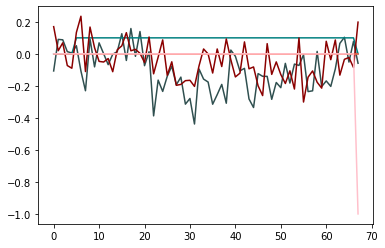

In [5]:
# Plot an example trial for teacher RNN

mante = Mante()
stimulus, targets, mask=mante.__getitem__(0)
plt.plot(stimulus[:,0], c='darkslategray')
plt.plot(stimulus[:,2], c='teal')
plt.plot(stimulus[:,1], c='darkred')
plt.plot(stimulus[:,3], c='tomato')

plt.plot(targets, c='pink')

In [6]:
task_params_teacher = {}
# train or load teacher RNN
if train_teacher:
    losses, reg_losses = train_rnn(
        rnn_reach, training_params, mante, sync_wandb=False
    )
    save_rnn(
        data_dir + "cdm_rnn2",
        rnn_reach,
        model_params,
        task_params_teacher,
        training_params,
    )
else:
    rnn_reach, model_params, task_params_teacher, training_params = load_rnn(
        data_dir + "cdm_rnn"
    )

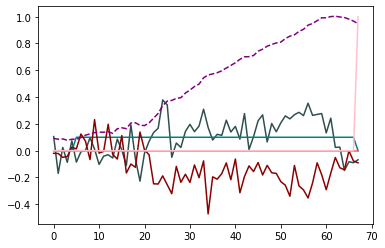

In [7]:
# Plot an example trial for teacher RNN with prediction
mante = Mante()
stimulus, targets, mask=mante.__getitem__(0)
rates, pred = predict(rnn_reach, stimulus)

plt.plot(stimulus[:,0], c='darkslategray')
plt.plot(stimulus[:,2], c='teal')
plt.plot(stimulus[:,1], c='darkred')
plt.plot(stimulus[:,3], c='tomato')

plt.plot(targets, c='pink')
plt.plot(pred[0,:,0], c='purple',ls='--')

In [8]:
# Extract weights
U, V, B = extract_orth_basis_rnn(rnn_reach)
I = rnn_reach.rnn.w_inp.detach()


In [9]:
class RDM_Teacher(Dataset):
    def __init__(self, task_params, task_params_teacher, U, V, B, I, decay=0.9):
        """
        Initialize Teacher data for Reaching task
        Args:
            task_params: dictionary containing task parameters
            task_params_teacher: dictionary containing teacher task parameters
            U: torch.tensor; N x R, input to hidden weights
            V: torch.tensor; R x N, hidden to hidden weights
            B: torch.tensor; N, biases
            I: torch.tensor; n_inp x N, input to hidden weights
            decay: float, decay rate
        """

        self.R_z = task_params["R_z"]
        self.R_x = task_params["R_x"]

        # obtain teacher RNNs stimuli
        mante = Mante(task_params_teacher)
        Reaching_loader = DataLoader(
            mante, batch_size=mante.__len__(), shuffle=False
        )
        n_repeats = (task_params["n_trials"]+1) //mante.__len__()

        ss =[]
        for _ in range(n_repeats):
            s, _, _ = next(iter(Reaching_loader))  # x = trial,time,stims
            ss.append(s)
        self.stim = torch.concatenate(ss[:task_params["n_trials"]])
        self.dur = self.stim.shape[1]
        self.n_trials=self.stim.shape[0]
        self.N = U.shape[0]
        self.non_lin = torch.nn.ReLU()

        # generate teacher data
        if "r0" in task_params:
            r0 = task_params["r0"]
        else:
            r0 = torch.randn(self.n_trials) * 0.1
        self.latents = torch.zeros(1, self.n_trials, self.dur, dtype=torch.float32)
        self.data = torch.zeros(self.N, self.n_trials, self.dur, dtype=torch.float32)
        self.latents[0, :, 0] = r0 
        self.latents[0, :, 0] += torch.randn(self.n_trials) * self.R_z
        v = torch.zeros(self.n_trials, self.dur,4, dtype=torch.float32)
        for t in range(1, self.dur):
            v[:,t] = decay * v[:, t - 1] + (1-decay)*(self.stim[:, t - 1])
            self.latents[:, :, t] = decay * self.latents[:, :, t - 1]
            X = U @ self.latents[:, :, t - 1] + B.unsqueeze(1) + (v[:, t - 1] @ I).T
            self.latents[:, :, t] += (
                V @ self.non_lin(X) + torch.randn(self.n_trials) * self.R_z
            )

        if task_params["out"] == "rates":
            for t in range(self.dur):
                self.data[:, :, t] = self.non_lin(
                    U @ self.latents[:, :, t] + B.unsqueeze(1) + (v[:, t] @ I).T
                )
        elif task_params["out"] == "currents":
            for t in range(self.dur):
                self.data[:, :, t] = U @ self.latents[:, :, t] + (v[:, t] @ I).T
        self.data += torch.randn(self.N, self.n_trials, self.dur) * self.R_x
        self.data_eval = self.data
        self.task_params = task_params
        self.v=v

    def __len__(self):
        """Return number of trials in an epoch"""
        return self.n_trials

    def __getitem__(self, idx):
        """
        Return a trial of length self.dur
        Args:
            idx (int): trial index
        Returns:
            trial (torch.tensor; dim_x x self.dur): trial of length self.dur
            stim (torch.tensor; n_inp x self.dur): stimulus
        """
        stim = self.stim[idx].T.to(device=self.data.device)
        return self.data[:, idx], stim#torch.zeros(0,self.dur,dtype=torch.float32,device=stim.device)#stim



In [10]:
# Generate data using teacher RNN, used for training student RNN
batch_size = 4
task_params = {
    "name": "rdm",
    "n_neurons": rnn_reach.rnn.N,
    "out": "currents",
    "r0": 0,
    "R_x": 0.1,
    "R_z": 0.05,
    "n_trials": 400,
}
task = RDM_Teacher(task_params, task_params_teacher, U, V, B, I, decay=0.9)
data_loader = DataLoader(task, batch_size=batch_size, shuffle=True)

In [11]:
# Initialise VI / student setup

dim_z = 1
dim_N = task_params["n_neurons"]
dim_x = task_params["n_neurons"]
dim_u = 4
bs = 10
cuda = True
n_epochs = 500
wandb = False
# initialise encoder
enc_params = {"obs_grad": True, "init_scale": 0.1}

# initialise prior
prior_params = {
    "train_noise_x": True,
    "train_noise_z": True,
    "train_noise_z_t0": True,
    "init_noise_z": 0.1,
    "init_noise_z_t0": 1,
    "init_noise_x": 0.1,
    "scalar_noise_z": "Cov",
    "scalar_noise_x": False,
    "scalar_noise_z_t0": "Cov",
    "identity_readout": True,
    "activation": "relu",
    "exp_par": True,
    "shared_tau": 0.7,
    "readout_rates": task_params["out"],
    "train_obs_bias": False,
    "train_obs_weights": False,
    "train_latent_bias": False,
    "train_neuron_bias": True,
    "orth": False,
    "m_norm": False,
    "weight_dist": "uniform",
    "weight_scaler": 1,  # /dim_N,
    "initial_state": "trainable",
    "out_nonlinearity": "identity"
}


training_params = {
    "lr": 1e-3,
    "lr_end": 1e-5,
    "step_size":1,
    "opt_eps": 1e-8,
    "gamma":.99,
    "n_epochs": n_epochs,
    "grad_norm": 0,
    "bootstrap": False,
    "eval_epochs": 50,
    "batch_size": bs,
    "cuda": cuda,
    "smoothing": 20,
    "freq_cut_off": 10000,
    "sim_obs_noise": 0,
    "sim_latent_noise": 1,
    "k": 64,
    "loss_f": "opt_VGTF",
    "resample": "systematic",  # , multinomial or none"
    "run_eval": False,
    "smooth_at_eval": False,
    "sim_v":True,
    "neuromodulation":None
}


VAE_params = {
    "dim_x": dim_x,
    "dim_z": dim_z,
    "dim_u": dim_u,
    "dim_N": dim_N,
    "dim_s":0,
    "enc_architecture": "Inv_Obs",
    "enc_params": enc_params,
    "prior_architecture": "PLRNN",
    "prior_params": prior_params,
    "causal":True,
}
vae = VAE(VAE_params)

Neuromodulation type: None
using ReLU activation
using uniform init
weight scaler 1


In [12]:
vae, _,_,_ = load_model(name=model_dir + "mante_student")

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: None
using ReLU activation
using uniform init
weight scaler 1


In [13]:
# Train

train_VAE(
    vae,
    training_params,
    task,
    sync_wandb=wandb,
    out_dir=model_dir,
    fname=None,
    store_train_stats=False,
)

Training on : cpu
Learning rate decay factor 0.9908319448927676
epoch 1 loss: -24.5596, ll: 24.5596, ll_x: -25.0107, ll_z: -1.8734 H: 2.2975, alpha: 0.58, lr: 0.001000, N_z: 0.0436, N_x: 0.1504
epoch 2 loss: -24.7234, ll: 24.7234, ll_x: -25.1745, ll_z: -1.8752 H: 2.2988, alpha: 0.58, lr: 0.000990, N_z: 0.0435, N_x: 0.1504
epoch 3 loss: -25.0895, ll: 25.0895, ll_x: -25.5403, ll_z: -1.8780 H: 2.3011, alpha: 0.58, lr: 0.000980, N_z: 0.0433, N_x: 0.1504
epoch 4 loss: -25.3800, ll: 25.3800, ll_x: -25.8293, ll_z: -1.8820 H: 2.3033, alpha: 0.57, lr: 0.000970, N_z: 0.0431, N_x: 0.1504
epoch 5 loss: -25.8013, ll: 25.8013, ll_x: -26.2495, ll_z: -1.8872 H: 2.3072, alpha: 0.57, lr: 0.000961, N_z: 0.0428, N_x: 0.1504
epoch 6 loss: -26.1643, ll: 26.1643, ll_x: -26.6119, ll_z: -1.8916 H: 2.3108, alpha: 0.57, lr: 0.000951, N_z: 0.0426, N_x: 0.1503
epoch 7 loss: -26.5594, ll: 26.5594, ll_x: -27.0058, ll_z: -1.8970 H: 2.3141, alpha: 0.57, lr: 0.000941, N_z: 0.0423, N_x: 0.1503
epoch 8 loss: -26.9768, ll

KeyboardInterrupt: 

In [14]:
save_model(vae, training_params, task_params, name=model_dir + "mante_student")

'../../models/students/mante_student'

In [15]:
#vae, _,_,_ = load_model(name=model_dir + "mante_student")

In [16]:
# extract teacher RNN data
batch_size=12
task_params['n_trials']=batch_size
task = RDM_Teacher(task_params, task_params_teacher, U, V, B, I, decay=0.9)
data_loader = DataLoader(task, batch_size=batch_size, shuffle=False)

ratesGT = task.data
latent_codeGT = task.latents

# run the student RNN
with torch.no_grad():
    z0 = torch.zeros(batch_size,1,1,1)
    stim = task.stim.permute(0, 2, 1)
    dur=task.dur
    Z, v = vae.rnn.get_latent_time_series(time_steps=dur, z0=z0, u=stim, noise_scale=1,sim_v=True)
    Zn = Z.cpu().detach().numpy()[:, :, :, 0]
    data_gen = (
        vae.rnn.get_observation(Z, v=v,noise_scale=1).cpu().detach().numpy()[:, :, :, 0]
    )

/var/folders/7z/c9g_hq_9025gxx730qgmlh4w0000gn/T/ipykernel_9340/1574588498.py:20: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')


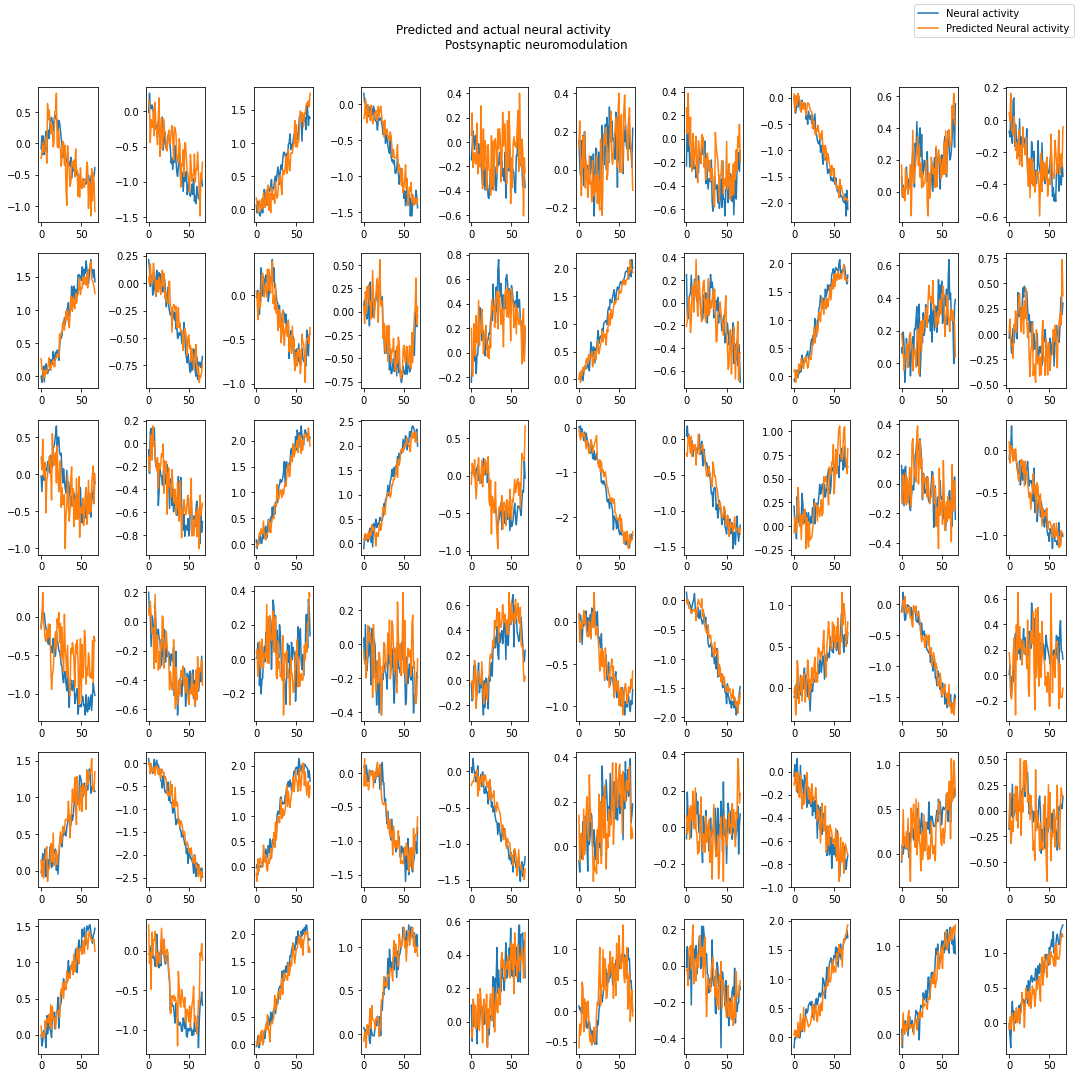

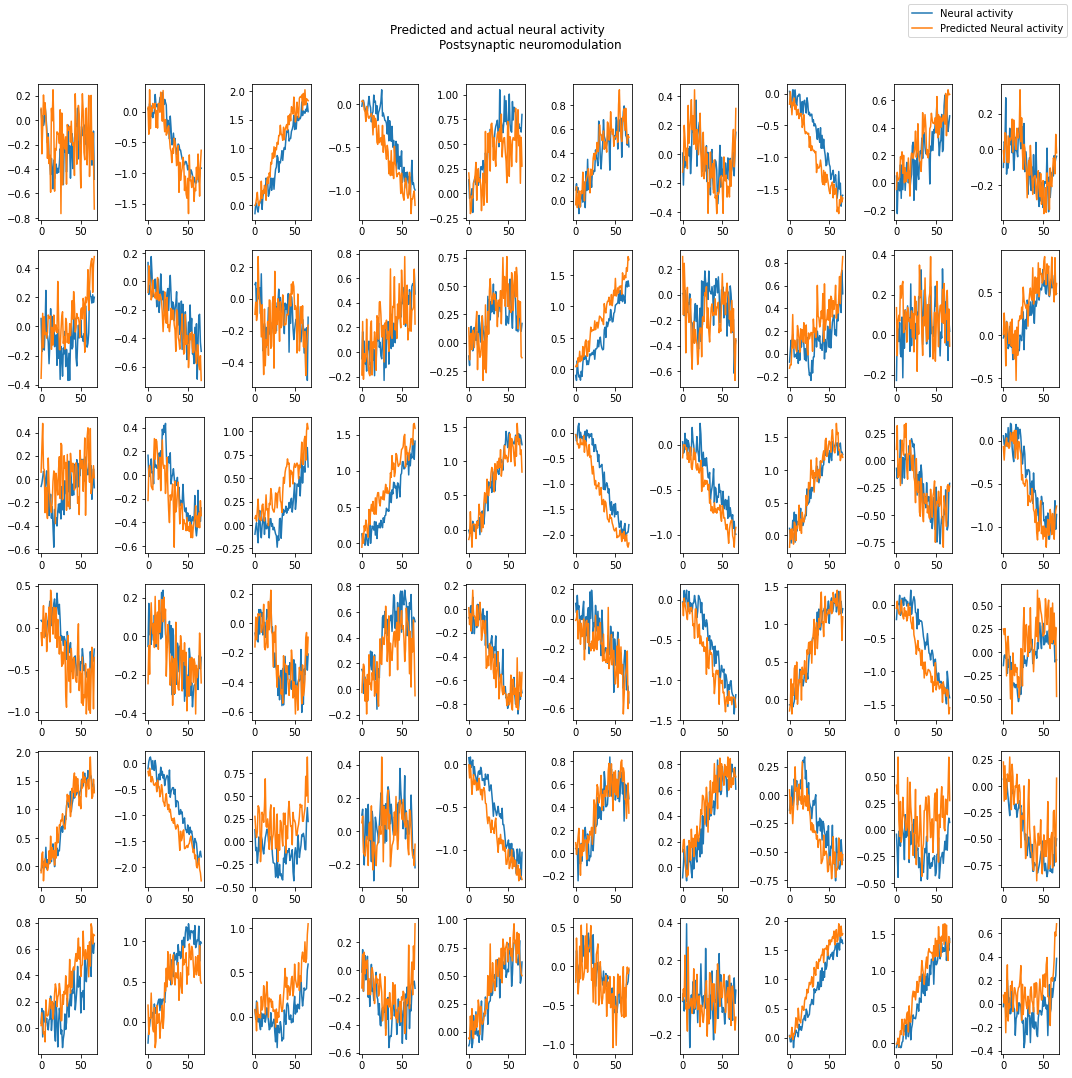

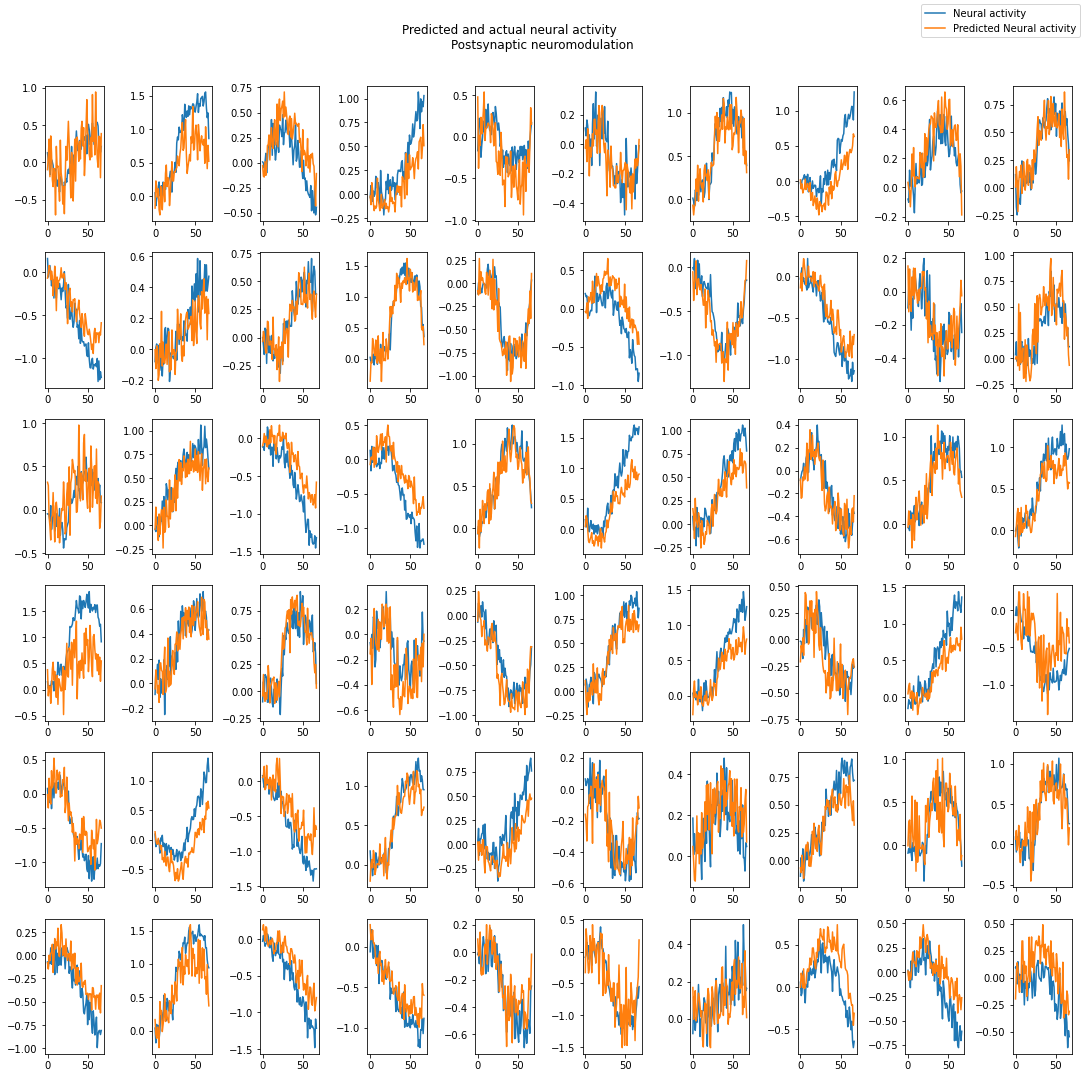

In [18]:
import matplotlib.pyplot as plt 
kl_div = []
for b in range(3):
    # compute the KL-Divergence 
    #kl_div_b = compute_KL_divergence(X_pred[b].unsqueeze(0), x[b])
    #kl_div.append(kl_div_b) 
    # plot population activity 
    fig, ax = plt.subplots(6, 10, figsize=(15, 15))
    idx_i, idx_j = 0, 0
    for i in range(task_params["n_neurons"]):
        ax[idx_i, idx_j].plot(ratesGT[i,b], label=f'Neural activity')
        #ax[idx_i, idx_j].plot(x[b+1, :, i], label=f'Neural activity')
        #ax[idx_i, idx_j].plot(X_pred[b+1, :, i], label=f'Predicted Neural activity')

        ax[idx_i, idx_j].plot(data_gen[b,i], label=f'Predicted Neural activity')
        idx_j += 1
        if idx_j >= 10: 
            idx_i, idx_j = idx_i + 1, 0
        
    fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')
    fig.suptitle(f"Predicted and actual neural activity\
                 \nPostsynaptic neuromodulation")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    #fig.savefig(f"{figures_dir}/reaching_unmodulated_{b}.png")
    # plt.show()
    
    

0.6801321547461321


Text(0.5, 1.0, 'Pearson $R$ heatmap')

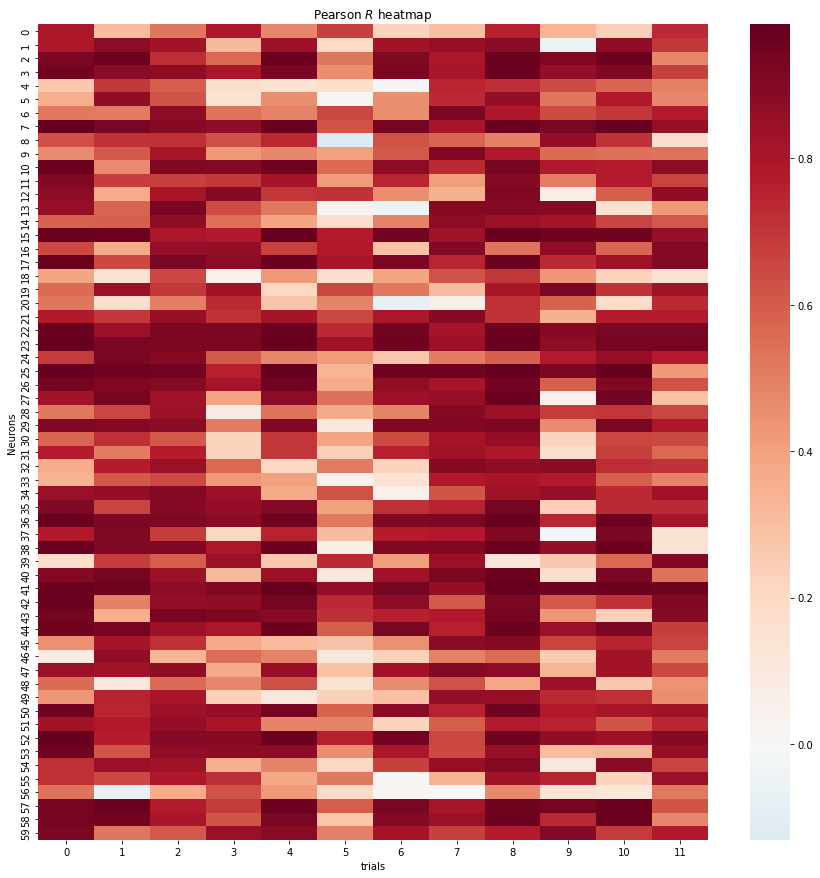

In [23]:
import seaborn as sns
from scipy.stats import pearsonr
# compute pearson's r

pearson_r = np.zeros((task_params["n_neurons"], data_gen.shape[0]))
for i in range(task_params["n_neurons"]):
    for b in range(data_gen.shape[0]):
        pearson_r[i][b] = pearsonr(ratesGT[i,b],data_gen[b,i])[0]
print(pearson_r.mean())
plt.figure(figsize=(15, 15))
# r2_arr[r2_arr < -1] = -1
sns.heatmap(pearson_r[:, :], annot=False, cmap='RdBu_r', center=0, cbar=True)
# x_ticks = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
# x_labels = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
# plt.xticks(x_ticks, x_labels)
plt.ylabel('Neurons')
plt.xlabel('trials')
plt.title(f'Pearson $R$ heatmap')
# plt.savefig('rank_scaling_pearson_r.png')